In [2]:
import pandas as pd

df=pd.read_csv('cleaned_data.csv')

In [10]:
df

,Company_Name,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Language,Engagement_Score,Customer_Segment,ROI,Profit_Loss
0,nykaa,Social Media,College Students,21.000000,"WhatsApp, YouTube",57804.0,6156.000000,3616.0,2355.000000,1867515.0,384.499606,Hindi,20.980000,College Students,4856.001078,Profit
1,nykaa,Paid Ads,Tier 2 City Customers,18.000000,YouTube,91801.0,3321.000000,1971.0,1357.000000,1046247.0,180.830000,Hindi,7.240000,College Students,5784.804347,Profit
2,nykaa,Influencer,Youth,23.000000,"WhatsApp, Google, YouTube",15536.0,2182.000000,952.0,755.000000,197055.0,90.600000,English,25.030000,College Students,2174.000000,Profit
3,nykaa,Paid Ads,College Students,10.000000,"Facebook, Instagram",96871.0,3743.000000,2060.0,1258.000000,518296.0,228.600000,Hindi,7.290000,Tier 2 City Customers,2266.261592,Profit
4,nykaa,Paid Ads,College Students,21.000000,"YouTube, Google, WhatsApp",82267.0,4687.643065,1873.0,1386.000000,633402.0,210.170000,Tamil,14.066269,Youth,3012.760289,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129227,tira,Social Media,Premium Shoppers,14.000000,Instagram,38933.0,2683.000000,1307.0,931.000000,641459.0,298.630000,Hindi,13.860726,Premium Shoppers,2147.005894,Profit
129228,tira,Influencer,Premium Shoppers,15.000000,"WhatsApp, YouTube, Google",25929.0,1388.000000,808.0,567.000000,408240.0,258.430000,Hindi,10.660000,Working Women,1578.692760,Profit
129229,tira,SEO,Working Women,20.000000,"Google, Instagram",54886.0,1578.000000,634.0,336.065654,136514.0,436.240000,English,4.660000,Working Women,311.933248,Profit
129230,tira,Influencer,Premium Shoppers,22.000000,"Google, Email",11669.0,4687.643065,122.0,44.000000,26884.0,348.449329,English,5.350000,Working Women,76.153255,Profit


In [35]:
df.groupby('Channel_Used')['Company_Name'].unique()

Channel_Used
Email                           [nykaa, purplle, tira]
Email, Facebook                 [nykaa, purplle, tira]
Email, Facebook, Google         [nykaa, purplle, tira]
Email, Facebook, Instagram      [nykaa, purplle, tira]
Email, Facebook, WhatsApp       [nykaa, purplle, tira]
                                         ...          
YouTube, WhatsApp               [nykaa, purplle, tira]
YouTube, WhatsApp, Email        [nykaa, purplle, tira]
YouTube, WhatsApp, Facebook     [nykaa, purplle, tira]
YouTube, WhatsApp, Google       [nykaa, purplle, tira]
YouTube, WhatsApp, Instagram    [nykaa, purplle, tira]
Name: Company_Name, Length: 156, dtype: object

In [8]:
df["Customer_Segment"].unique()

<ArrowStringArray>
[     'College Students', 'Tier 2 City Customers',                 'Youth',
      'Premium Shoppers',         'Working Women']
Length: 5, dtype: str

In [3]:
df.columns.tolist()

['Company_Name',
 'Campaign_Type',
 'Target_Audience',
 'Duration',
 'Channel_Used',
 'Impressions',
 'Clicks',
 'Leads',
 'Conversions',
 'Revenue',
 'Acquisition_Cost',
 'Language',
 'Engagement_Score',
 'Customer_Segment',
 'ROI',
 'Profit_Loss']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


In [12]:
# import model sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [13]:
x = df.drop(columns=['Profit_Loss'])
y =df['Profit_Loss']


In [14]:
# categorical Columns one-hot encoding
categorical_cols= x.select_dtypes(include=['object','string','category']).columns.tolist()

preprocessor =ColumnTransformer(transformers=[('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False)
                                              ,categorical_cols)],remainder='passthrough'
                                              )

In [15]:
# train \test split
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.3,random_state=10,stratify=y)


In [16]:

from imblearn.over_sampling import SMOTE


x_train_enc = preprocessor.fit_transform(x_train) 


smote = SMOTE(random_state=10, k_neighbors=1)

x_train_res, y_train_res = smote.fit_resample(x_train_enc, y_train)

print("------oversampling(original Train data):-------")
print(y_train.value_counts())
print(y_train_res.value_counts())

------oversampling(original Train data):-------
Profit_Loss
Profit    85999
Loss       4463
Name: count, dtype: int64
Profit_Loss
Profit    85999
Loss      85999
Name: count, dtype: int64


In [17]:
# model metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_classification(name, y_true, y_pred):
    return {
        'Model': name,
        'ACCURACY': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }


In [18]:
from imblearn.pipeline import Pipeline as ImbPipeline

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=20),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=50, random_state=40)
}

results = []
best_pipeline = None
best_accuracy = -1

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=10)),
        ('model', model)
    ])
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)

    res= evaluate_classification(name, y_test, y_pred)
    results.append(res)
    

    accuracy = accuracy_score(y_test, y_pred)
    if results[-1]['ACCURACY'] > best_accuracy:
        best_accuracy = results[-1]['ACCURACY']
        best_pipeline = pipeline


best_clf_model = pd.DataFrame(results).sort_values(by='ACCURACY', ascending=False).reset_index(drop=True)
display(best_clf_model)

,Model,ACCURACY,Precision,Recall,F1
0,LogisticRegression,1.0,1.0,1.0,1.0
1,DecisionTreeClassifier,1.0,1.0,1.0,1.0
2,RandomForestClassifier,1.0,1.0,1.0,1.0


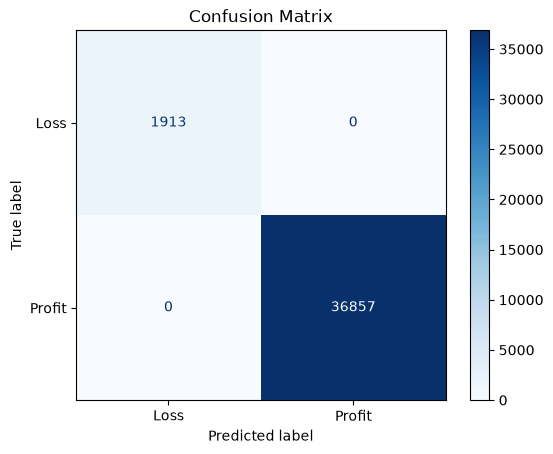

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss', 'Profit'])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [20]:
import pickle

with open('LogisticRegression.pkl','wb') as file:
    pickle.dump(best_clf_model,file)

print('Model saved successfully.')

Model saved successfully.
